# 1.0 Inicialización

In [9]:
%pip install kagglehub scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1.2 Categorización

In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:

# Definir los directorios base y de destino
base_dir = 'Shoe vs Sandal vs Boot Dataset'
train_dir = 'train'
test_dir = 'test'

# Verificar y eliminar solo si es un directorio
if os.path.exists(train_dir) and os.path.isdir(train_dir):
    shutil.rmtree(train_dir)
elif os.path.exists(train_dir):
    os.remove(train_dir)  # Eliminar si es un archivo

if os.path.exists(test_dir) and os.path.isdir(test_dir):
    shutil.rmtree(test_dir)
elif os.path.exists(test_dir):
    os.remove(test_dir)  # Eliminar si es un archivo


# Crear carpetas para train y test
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Listar las categorías (subcarpetas) en el directorio base
categories = os.listdir(base_dir)

# Para cada categoría, copiar imágenes a las carpetas de train y test
for category in categories:
    category_path = os.path.join(base_dir, category)

    # Verificar que sea un directorio y que no esté vacío
    if os.path.isdir(category_path) and os.listdir(category_path):
        images = os.listdir(category_path)

        # Dividir las imágenes en conjuntos de entrenamiento y prueba
        train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

        # Crear rutas para las subcarpetas de train y test
        train_category_path = os.path.join(train_dir, category)
        test_category_path = os.path.join(test_dir, category)

        os.makedirs(train_category_path, exist_ok=True)
        os.makedirs(test_category_path, exist_ok=True)

        # Copiar las imágenes al directorio de entrenamiento
        for img in train_images:
            src_path = os.path.join(category_path, img)
            dest_path = os.path.join(train_category_path, img)
            if not os.path.exists(dest_path):
                shutil.copy2(src_path, dest_path)

        # Copiar las imágenes al directorio de prueba
        for img in test_images:
            src_path = os.path.join(category_path, img)
            dest_path = os.path.join(test_category_path, img)
            if not os.path.exists(dest_path):
                shutil.copy2(src_path, dest_path)

print("Copias completadas. Las imágenes originales permanecen en su ubicación inicial.")


## 1.3 Visualización

In [ ]:
%pip install opencv-python

   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.8 MB 9.6 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/38.8 MB 12.0 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/38.8 MB 13.3 MB/s eta 0:00:03
   ---------- ----------------------------- 10.2/38.8 MB 13.3 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/38.8 MB 13.7 MB/s eta 0:00:02
   -------------- ------------------------- 14.4/38.8 MB 12.2 MB/s eta 0:00:02
   ----------------- ---------------------- 17.0/38.8 MB 12.3 MB/s eta 0:00:02
   -------------------- ------------------- 19.9/38.8 MB 12.3 MB/s eta 0:00:02
   ----------------------- ---------------- 22.8/38.8 MB 12.4 MB/s eta 0:00:02
   -------------------------- ------------- 25.7/38.8 MB 12.8 MB/s eta 0:00:02
   ----------------------------- ---------- 28.3/38.8 MB 12.6 MB/s eta 0:00:01
   ------------------------------ --------- 29.4/38.8 MB 12.2 MB/

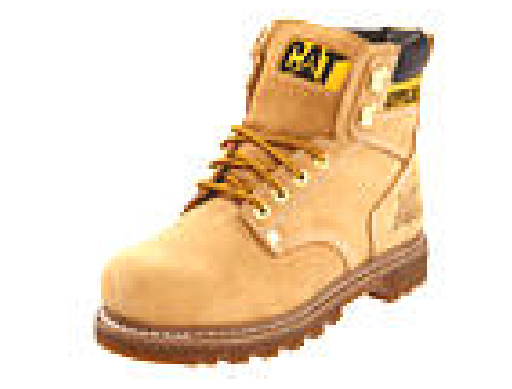

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Escogiendo y mostrando una imagen al azar del conjunto de test
idx = np.random.randint(1, 50)  # Ajusta el rango si es necesario
image_path = f'./train/Boot/boot ({idx}).jpg'

# Verifica si el archivo existe
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir a RGB para matplotlib
    plt.imshow(img)
    plt.axis('off')  # Ocultar ejes
    plt.show()
else:
    print("La imagen no existe en la ruta especificada:", image_path)

## 1.4 Dividir

In [19]:
%pip install tensorflow

   ---------------------------------------- 0.0/390.2 MB ? eta -:--:--
   ---------------------------------------- 1.6/390.2 MB 10.5 MB/s eta 0:00:38
   ---------------------------------------- 3.4/390.2 MB 8.7 MB/s eta 0:00:45
    --------------------------------------- 5.2/390.2 MB 8.8 MB/s eta 0:00:44
    --------------------------------------- 7.3/390.2 MB 9.1 MB/s eta 0:00:43
   - -------------------------------------- 10.2/390.2 MB 10.1 MB/s eta 0:00:38
   - -------------------------------------- 13.4/390.2 MB 10.9 MB/s eta 0:00:35
   - -------------------------------------- 16.8/390.2 MB 11.6 MB/s eta 0:00:33
   - -------------------------------------- 18.6/390.2 MB 11.3 MB/s eta 0:00:33
   -- ------------------------------------- 21.2/390.2 MB 11.6 MB/s eta 0:00:32
   -- ------------------------------------- 24.6/390.2 MB 11.9 MB/s eta 0:00:31
   -- ------------------------------------- 27.5/390.2 MB 12.2 MB/s eta 0:00:30
   --- ------------------------------------ 29.4/390.2 M

  You can safely remove it manually.
  You can safely remove it manually.


In [3]:
# Definir los directorios base y de destino
base_dir = 'Shoe vs Sandal vs Boot Dataset'
train_dir = 'train'
test_dir = 'test'

In [4]:
import tensorflow as tf
import numpy as np

# Cargar las imágenes desde las carpetas en datasets de TensorFlow
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    batch_size=8,
    image_size=(64, 64),
    shuffle=True  # Mezclamos las imágenes
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='int',
    batch_size=4,
    image_size=(64, 64),
    shuffle=False  # No es necesario barajar en el conjunto de test
)

def dataset_to_numpy(dataset):
    """Convierte un dataset de TensorFlow a arrays de NumPy."""
    images = []
    labels = []
    for img_batch, lbl_batch in dataset:
        images.append(img_batch.numpy())
        labels.append(lbl_batch.numpy())

    # Concatenar solo al final para mejorar eficiencia
    return np.concatenate(images), np.concatenate(labels)

# Convertir el dataset de entrenamiento a NumPy arrays
x_train, y_train = dataset_to_numpy(train_dataset)
x_test, y_test = dataset_to_numpy(test_dataset)

# Verificar las dimensiones
print("Shape de x_train:", x_train.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de x_test:", x_test.shape)
print("Shape de y_test:", y_test.shape)


Found 12000 files belonging to 3 classes.
Found 3000 files belonging to 3 classes.
Shape de x_train: (12000, 64, 64, 3)
Shape de y_train: (12000,)
Shape de x_test: (3000, 64, 64, 3)
Shape de y_test: (3000,)


# 2.0 Red Neuronal - Tensorflow

In [6]:
%pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


Requested tensorflow-gpu from https://files.pythonhosted.org/packages/8a/45/fa31ced1db38f9424f262dfbf35747fe5378b5c808cecb373c8cb8e515d3/tensorflow-gpu-2.12.0.tar.gz has invalid metadata: Expected end or semicolon (after name and no valid version specifier)
    python_version>"3.7"
                  ^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement tensorflow-gpu (from versions: 2.12.0)
ERROR: No matching distribution found for tensorflow-gpu


In [16]:
# Verificando el uso de la GPU
import tensorflow as tf
print("Dispositivos disponibles:", tf.config.list_physical_devices())

Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2.1 Preparación


In [17]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
#One-hot encoding para minimizar error
y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
print(y_train.shape)

y_te = to_categorical(y_test, num_classes=3)

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(12000, 3)
(10800, 3)


In [18]:
print(y_te.shape)

(3000, 3)


## 2.2 Modelado

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout

#Topología
model = Sequential()
#Incrementar el tamaño de la imagen
model.add(Input(shape=(64, 64)))  # Usar Input como la primera capa
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(10, activation="softmax"))

In [20]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# define cómo se ajustará el modelo durante el entrenamiento para minimizar los errores de clasificación.
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [21]:
from tensorflow.keras.models import Model

input_layer = Input(shape=(64, 64, 3))
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
x= Dropout(0.5)(x)
output_layer = Dense(3, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

In [22]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,293,507 (24.01 MB)

 Trainable params: 6,293,507 (24.01 MB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

## 2.3 Entrenamiento Simple

Empeora con batchsize menores a 16. Tal vez probar 32 o 128.
Epoch en 100 pueden probar si la RAM se los permite

In [24]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=64)

[INFO]: Entrenando red neuronal...
Epoch 1/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5854 - loss: 1.2569 - val_accuracy: 0.8142 - val_loss: 0.4852
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7709 - loss: 0.5520 - val_accuracy: 0.8383 - val_loss: 0.4139
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8080 - loss: 0.4838 - val_accuracy: 0.8550 - val_loss: 0.3750
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8317 - loss: 0.4305 - val_accuracy: 0.8633 - val_loss: 0.3524
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8346 - loss: 0.4171 - val_accuracy: 0.8617 - val_loss: 0.3447
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8393 - loss: 0.4143 - val_accuracy: 0.8567 - val_loss: 0.3777
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8593 - loss: 0.3711 - val_accuracy: 0.8817 - val_loss: 0.3105
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accurac

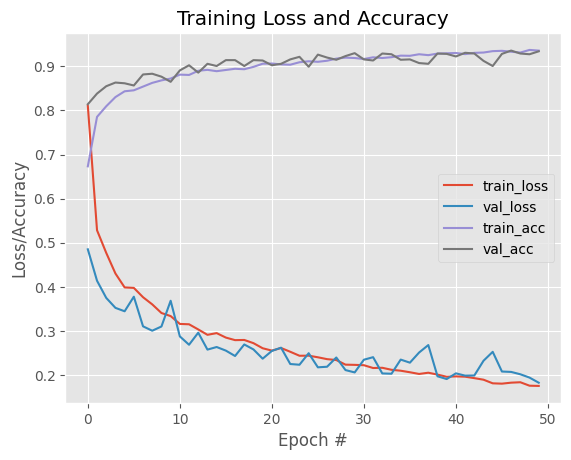

In [25]:
# Muestro gráfica de accuracy y losses
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

Matriz de confusión

### 2.3.1 Evaluación

In [26]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))


[INFO]: Evaluando red neuronal...
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[1. 0. 0.]
[9.9019998e-01 9.7945742e-03 5.3834665e-06]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1000
           1       0.92      0.92      0.92      1000
           2       0.92      0.94      0.93      1000

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



In [27]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,293,509 (24.01 MB)

 Trainable params: 6,293,507 (24.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


# 2.0 Red Neuronal - Pytorch

## 2.1 Preparación


In [45]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch.nn as nn

# Normalización al rango 0-1
print("Normalizando datos...")
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convertir a tensores de PyTorch
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)  # Etiquetas inicialmente flotantes
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Convertir etiquetas de one-hot a índices de clase
if y_train_tensor.dim() > 1:
    y_train_tensor = torch.argmax(y_train_tensor, dim=1)
if y_test_tensor.dim() > 1:
    y_test_tensor = torch.argmax(y_test_tensor, dim=1)

# Verificar la forma después de la conversión
print(f"y_train_tensor.shape después de conversión: {y_train_tensor.shape}")
print(f"Ejemplo de etiquetas y_train_tensor (valores únicos): {torch.unique(y_train_tensor)}")

# Verificar tipos de datos
print(f"x_train_tensor.dtype: {x_train_tensor.dtype}")
print(f"y_train_tensor.dtype: {y_train_tensor.dtype}")

# Dividir en subconjuntos de entrenamiento y validación
print("Dividiendo en conjuntos de entrenamiento y validación...")
x_tr, x_val, y_tr, y_val = train_test_split(x_train_tensor, y_train_tensor, test_size=0.1, random_state=42)

# Crear DataLoaders
print("Creando DataLoaders...")
train_dataset = TensorDataset(x_tr, y_tr)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=128)

# Verificar las etiquetas
print(f"Ejemplo de etiquetas y_tr (valores únicos): {torch.unique(y_tr)}")
print(f"Ejemplo de etiquetas y_val (valores únicos): {torch.unique(y_val)}")

Normalizando datos...
y_train_tensor.shape después de conversión: torch.Size([12000])
Ejemplo de etiquetas y_train_tensor (valores únicos): tensor([0, 1, 2])
x_train_tensor.dtype: torch.float32
y_train_tensor.dtype: torch.int64
Dividiendo en conjuntos de entrenamiento y validación...
Creando DataLoaders...
Ejemplo de etiquetas y_tr (valores únicos): tensor([0, 1, 2])
Ejemplo de etiquetas y_val (valores únicos): tensor([0, 1, 2])


## 2.2 Modelado

In [46]:
# Definir el modelo
print("Definiendo el modelo...")
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 64 * 3, 512)  # 64x64x3 es el tamaño de entrada
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 3)  # 3 clases para la salida

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # No aplicar softmax aquí

model = SimpleNN()
print(model)

Definiendo el modelo...
SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)


In [47]:
# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
model.to(device)

Usando dispositivo: cuda


SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

## 2.3 Entrenamiento Simple

In [57]:
# Configurar pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

# Bucle de entrenamiento
print("Comenzando entrenamiento...")
num_epochs = 50 

# Inicializar listas para las métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (x_batch, y_batch) in enumerate(train_loader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calcular precisión para el conjunto de entrenamiento
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    # Validación
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for x_val_batch, y_val_batch in val_loader:
            x_val_batch, y_val_batch = x_val_batch.to(device), y_val_batch.to(device)
            outputs = model(x_val_batch)
            loss = criterion(outputs, y_val_batch)
            val_loss += loss.item()

            # Calcular precisión para el conjunto de validación
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == y_val_batch).sum().item()
            total_val += y_val_batch.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_accuracy = correct_val / total_val
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
            f"Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, Validation Acc: {val_accuracy:.4f}")

Comenzando entrenamiento...
Epoch [1/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3340, Validation Acc: 0.3217
Epoch [2/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3317, Validation Acc: 0.3217
Epoch [3/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3285, Validation Acc: 0.3217
Epoch [4/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3330, Validation Acc: 0.3217
Epoch [5/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3271, Validation Acc: 0.3217
Epoch [6/50] - Train Loss: 1.0987, Validation Loss: 1.0987, Train Acc: 0.3317, Validation Acc: 0.3217
Epoch [7/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3340, Validation Acc: 0.3217
Epoch [8/50] - Train Loss: 1.0987, Validation Loss: 1.0987, Train Acc: 0.3293, Validation Acc: 0.3217
Epoch [9/50] - Train Loss: 1.0986, Validation Loss: 1.0987, Train Acc: 0.3369, Validation Acc: 0.3217
Epoch [10/50] - Train Loss: 1.0987, Validation Loss: 1

In [58]:
# Validación del modelo
print("Comenzando validación...")
model.eval()
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)  # Obtener la clase predicha
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {correct/total:.4f}")


Comenzando validación...
Validation Loss: 1.0987, Accuracy: 0.3217


### 2.3.1 Evaluación

In [59]:
# Evaluación del modelo
print("Comenzando evaluación en test set...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)  # Obtener la clase predicha
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))


Comenzando evaluación en test set...
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1000
         1.0       0.00      0.00      0.00      1000
         2.0       0.33      1.00      0.50      1000

    accuracy                           0.33      3000
   macro avg       0.11      0.33      0.17      3000
weighted avg       0.11      0.33      0.17      3000



C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.

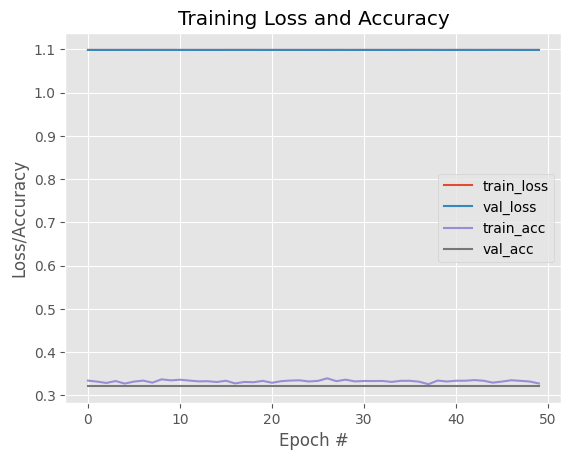

In [60]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")
plt.figure()

# Graficar pérdidas
epochs = np.arange(0, num_epochs)
plt.plot(epochs, train_losses, label="train_loss")
plt.plot(epochs, val_losses, label="val_loss")

# Graficar precisión
plt.plot(epochs, train_accuracies, label="train_acc")
plt.plot(epochs, val_accuracies, label="val_acc")

# Configurar gráfico
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# 3.0 CNN Augmentation

## 3.1 Preparación

In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# GRADED FUNCTION: train_val_generators
def train_val_generators(TRAINING_DIR, VALIDATION_DIR):
    """
    Creates the training and validation data generators for a multi-class dataset

    Args:
        TRAINING_DIR (string): directory path containing the training images
        VALIDATION_DIR (string): directory path containing the validation images

    Returns:
        train_generator, validation_generator - tuple containing the generators
    """

    # Generador para las imágenes de entrenamiento
    train_datagen = ImageDataGenerator(rescale=1.0/255.0)

    train_generator = train_datagen.flow_from_directory(
        directory=TRAINING_DIR,
        batch_size=20,
        class_mode='categorical',  # Cambiado a 'categorical' para 3 clases
        target_size=(150, 150)
    )

    # Generador para las imágenes de validación
    validation_datagen = ImageDataGenerator(rescale=1.0/255.0)

    validation_generator = validation_datagen.flow_from_directory(
        directory=VALIDATION_DIR,
        batch_size=20,
        class_mode='categorical',  # Cambiado a 'categorical' para 3 clases
        target_size=(150, 150)
    )

    return train_generator, validation_generator


## 3.2 Modelado

In [62]:
# ipython-input-46-0b58d1cd8478
from tensorflow.keras.optimizers import RMSprop
import tensorflow as tf


# GRADED FUNCTION: create_model
def create_model():
    # Define un modelo de Keras para clasificar entre zapato, sandalia y bota
    # Usa al menos 3 capas convolucionales
    model = tf.keras.models.Sequential([
        # Primera capa convolucional con tamaño de entrada 150x150 y 3 canales de color
        tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        # Corrected typo: MaxPoolinag2D to MaxPooling2D
        tf.keras.layers.MaxPooling2D(2,2),
        # Aplana los resultados para conectarlos con una red densa
        tf.keras.layers.Flatten(),
        # Capa densa con 512 neuronas
        tf.keras.layers.Dense(512, activation='relu'),
        # Capa de salida con 3 neuronas, una para cada clase (zapato, sandalia y bota)
        tf.keras.layers.Dense(3, activation='softmax')  # Cambiado a 3 clases con activación softmax
    ])

    # Compila el modelo usando una pérdida para clasificación multiclase
    model.compile(optimizer=RMSprop(learning_rate=0.001),
                  # Changed loss function to 'categorical_crossentropy' to match one-hot encoded labels
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [63]:
TRAINING_DIR = './train'
VALIDATION_DIR = './test'

In [64]:
train_generator, validation_generator = train_val_generators(TRAINING_DIR, VALIDATION_DIR)


Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


## 3.3 Entrenamiento

In [65]:
import tensorflow as tf

model = create_model()
history = model.fit(train_generator, validation_data=validation_generator, epochs=10)

C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.8216 - loss: 0.4535 - val_accuracy: 0.9587 - val_loss: 0.1171
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9635 - loss: 0.1019 - val_accuracy: 0.9667 - val_loss: 0.0994
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.9820 - loss: 0.0525 - val_accuracy: 0.9720 - val_loss: 0.0876
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9883 - loss: 0.0335 - val_accuracy: 0.9670 - val_loss: 0.1197
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.9914 - loss: 0.0217 - val_accuracy: 0.9737 - val_loss: 0.1317
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9954 - loss: 0.0149 - val_accuracy: 0.9750 - val_loss: 0.1551
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.9963 - loss: 0.0138 - val_accuracy: 0.9767 - val_loss: 0.1624
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - accuracy: 0.9975 - loss: 0.0096 - 

### 3.3.1 Evaluación

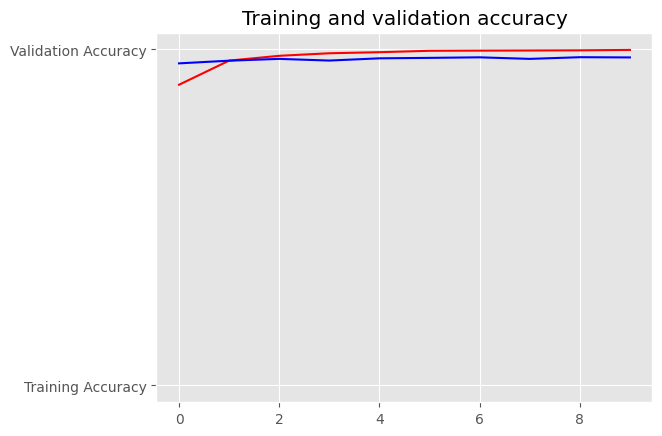

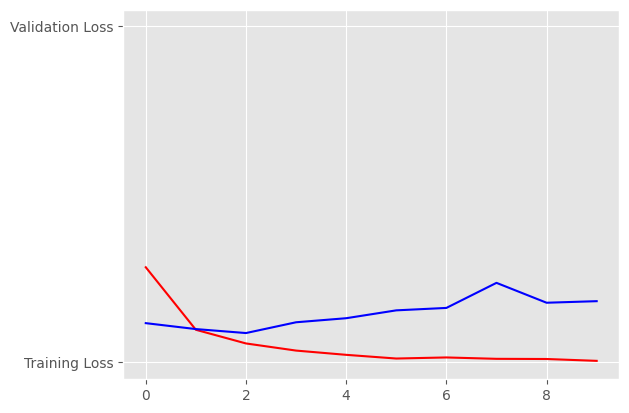

In [66]:
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.show()
print("")

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.show()

# 4.0 CNN Fine Tunning + Augmentation

In [8]:
# Ajustar datos que estaban en (64, 64) para llevarlos a (299, 299)
trainX_resized = tf.image.resize(x_train, (299, 299)).numpy()
testX_resized  = tf.image.resize(x_test, (299, 299)).numpy()

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definimos un generador de imágenes con técnicas de data augmentation
# para mejorar la capacidad de generalización del modelo. También realizamos
# un split del conjunto de entrenamiento en entrenamiento y validación.
datagen = ImageDataGenerator(
    rotation_range=15,        # grados de rotación aleatoria
    width_shift_range=0.2,    # fracción para desplazar la imagen en ancho
    height_shift_range=0.2,   # fracción para desplazar la imagen en alto
    horizontal_flip=True,     # voltear la imagen horizontalmente
    zoom_range=0.2,           # rango de zoom aleatorio
    validation_split=0.2      # separación de un 20% de datos para validación
)

## 4.1 Preparación

In [14]:
# Imports necesarios
from tensorflow.keras.applications import InceptionV3, imagenet_utils
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dropout, Flatten, GlobalMaxPooling2D, Dense
from tensorflow.keras import Model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.preprocessing import LabelBinarizer

# Asumiendo que ya tenemos x_train, y_train, x_test, y_test cargados y listos
# (tal como está en tu código original).
# Normalizamos las entradas utilizando la misma función de preprocesado
# que usa InceptionV3 en ImageNet.
trainX_resized = imagenet_utils.preprocess_input(trainX_resized)
testX_resized  = imagenet_utils.preprocess_input(testX_resized)

# Definimos los nombres de las clases (en tu caso son 3).
labelNames = ["boot", "sandal", "shoe"]

# Binarizamos las etiquetas (one-hot encoding).
lb = LabelBinarizer()
trainY = lb.fit_transform(y_train)
testY  = lb.transform(y_test)

## 4.2 Modelado

Detener el entrenamiento cuando ya no tenga un aprendizaje importante o cuando haya un sobre ajuste para evitar consumo de GPU

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

# Definimos dimensiones de nuestros datos de entrada (adaptada a InceptionV3).
input_shape = (299, 299, 3)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

# Mostramos la arquitectura del modelo base para ver la estructura
print(base_model.summary())

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

None


In [12]:
# Congelamos las capas iniciales del modelo para aprovechar los pesos pre-entrenados en ImageNet.
# En este ejemplo, congelamos todas las capas para un fine-tuning parcial.
for layer in base_model.layers:
    layer.trainable = False

# Tomamos la última capa del modelo base
last = base_model.layers[-1].output

# Añadimos nuestro clasificador en la parte superior (Top Model).
x = Flatten()(last)
x = BatchNormalization()(x)
x = Dense(500, activation='relu', name='fc1')(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(150, activation='relu', name='fc2')(x)
x = Dense(3, activation='softmax', name='predictions')(x)

# Construimos el modelo final combinando la base y el top model.
model = Model(base_model.input, x)

# Compilamos el modelo.
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callback para detener el entrenamiento cuando no haya mejoría.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Mostramos la arquitectura final con las capas entrenables.
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 87,941,175 (335.47 MB)

 Trainable params: 65,875,247 (251.29 MB)

 Non-trainable params: 22,065,928 (84.17 MB)

None


## 4.3 Entrenamiento

In [13]:
# Entrenamos la red usando el data augmentation. 
# subset="training" y subset="validation" hacen uso de validation_split=0.2,
# definido en nuestro datagen.

H = model.fit(
    datagen.flow(trainX_resized, trainY, batch_size=32, subset="training"),
    validation_data=datagen.flow(trainX_resized, trainY, batch_size=32, subset="validation"),
    epochs=50,
    verbose=1,
    callbacks=[early_stopping]
)

C:\Users\ALEX\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.5685 - loss: 1.0011 - val_accuracy: 0.7675 - val_loss: 0.5739
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7123 - loss: 0.6941 - val_accuracy: 0.7567 - val_loss: 0.5695
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.7427 - loss: 0.6284 - val_accuracy: 0.7975 - val_loss: 0.4987
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.7508 - loss: 0.5964 - val_accuracy: 0.7850 - val_loss: 0.5155
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.7577 - loss: 0.5759 - val_accuracy: 0.7900 - val_loss: 0.4804
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7613 - loss: 0.5535 - val_accuracy: 0.8142 - val_loss: 0.4585
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.7664 - loss: 0.5551 - val_accuracy: 0.8329 - val_loss: 0.4196
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7797 - loss: 0.5322 - val_accu

### 4.3.1 Evaluación

In [15]:
# Realizamos predicciones sobre el conjunto de test
predictions = model.predict(testX_resized, batch_size=64)

print(classification_report(
    testY.argmax(axis=1),
    predictions.argmax(axis=1),
    target_names=labelNames
))


47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step
              precision    recall  f1-score   support

        boot       0.76      0.19      0.30      1000
      sandal       0.44      0.90      0.59      1000
        shoe       0.59      0.41      0.48      1000

    accuracy                           0.50      3000
   macro avg       0.60      0.50      0.46      3000
weighted avg       0.60      0.50      0.46      3000



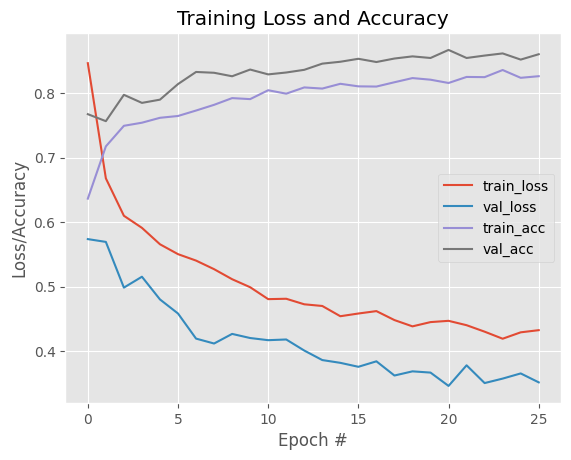

In [16]:
# Las pérdidas y accuracies finales pueden haber sido menos de 50 epochs
# si early_stopping detuvo el entrenamiento antes.
plt.style.use("ggplot")
plt.figure()
N = len(H.history["loss"])  # Número de épocas reales entrenadas

plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

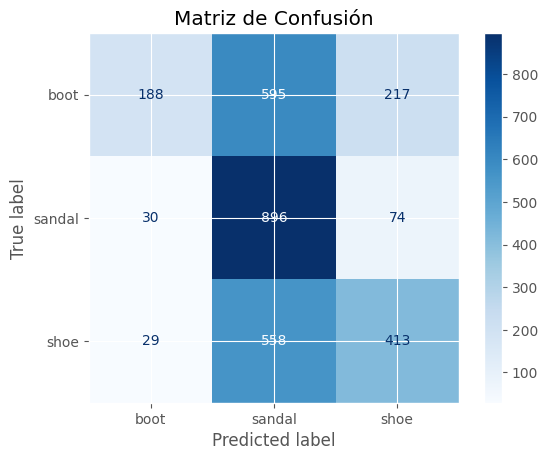

In [17]:
# Ahora añadimos la matriz de confusión para evaluar mejor la performance por clase.
cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))

# Graficamos la matriz de confusión de forma sencilla con sklearn.

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelNames)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()